# CRPS and PIT: interactive explorers

ELG 5218 — Performance metrics and calibration

This notebook has four interactive parts:

1. **CRPS as an area**: the forecast CDF $F(t)$, the observation step $H(t)$, and the squared gap whose area is CRPS.
2. **PIT for one prediction**: where the observation lands in its own predictive distribution.
3. **PIT histogram explorer**: why too-narrow forecasts give a U shape, too-wide forecasts give a hump, and a biased mean gives a slope.
4. **Three cases side by side**: a static summary.

Move the sliders; the plots update. Requires `numpy`, `scipy`, `matplotlib`, and `ipywidgets` (preinstalled in Colab; otherwise `pip install ipywidgets`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from ipywidgets import interact, FloatSlider, IntSlider

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

BLUE, RED, PURPLE, GREEN = "#27408B", "#C0392B", "#7F77DD", "#2E7D6B"
trapz = getattr(np, "trapezoid", None) or np.trapz   # works with NumPy 1.x and 2.x

def crps_gaussian(y, m, s):
    # Closed-form CRPS of N(m, s^2) at observation y
    z = (y - m) / s
    return s * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))

## 1. CRPS as an area

For each threshold $t$ the forecast answers the yes/no question *“Will the temperature be $\le t$?”* with probability $F(t)$.
After the observation $y$ is known, the true answer is $H(t)=\mathbf 1\{y\le t\}$ (0 = no, 1 = yes).

The penalty for one question is $[F(t)-H(t)]^2$: 0 if the forecast was sure and right, 1 if it was sure and wrong.
CRPS adds these penalties along the temperature axis:
$$
\mathrm{CRPS}=\int_{-\infty}^{\infty}[F(t)-H(t)]^2\,dt \quad(\text{in }{}^\circ\mathrm C).
$$

**Try:**
- Forecast SD → 0.05: the forecast becomes a point; the shaded region becomes a rectangle of height 1 and CRPS → $|y-\text{mean}|$.
- Observation = forecast mean: CRPS is not zero; a spread-out forecast pays for hedging near its centre.
- Observation 22, forecast SD 0.5, 2, 5: CRPS = 1.72, 1.21, 1.48. Too sure and too vague both cost.

In [2]:
def crps_explorer(y_obs=22.0, mean=20.0, sd=2.0):
    t = np.linspace(8, 32, 4001)
    F = norm.cdf(t, mean, sd)
    H = (t >= y_obs).astype(float)
    gap2 = (F - H) ** 2
    area = trapz(gap2, t)

    fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True, gridspec_kw={"height_ratios": [1.2, 1]})
    ax[0].fill_between(t, F, H, color=PURPLE, alpha=0.18, label="gap $F-H$")
    ax[0].plot(t, F, color=BLUE, lw=2.5, label="forecast CDF $F(t)$")
    ax[0].step(t, H, where="post", color=RED, lw=2, ls="--", label="observation step $H(t)$")
    for tt in [18, 20, 21, 23]:
        Ft, Ht = norm.cdf(tt, mean, sd), float(tt >= y_obs)
        ax[0].plot([tt, tt], [min(Ft, Ht), max(Ft, Ht)], color="#B7791F", lw=2)
    ax[0].set_ylabel("probability of $Y\\leq t$")
    ax[0].legend(loc="upper left", frameon=False)
    ax[0].set_title(f"Forecast N({mean:.1f}, {sd:.2f}²), observed y = {y_obs:.1f}")

    ax[1].fill_between(t, gap2, color=PURPLE, alpha=0.45)
    ax[1].plot(t, gap2, color=PURPLE, lw=1.5)
    ax[1].axvline(y_obs, color=RED, ls="--", lw=1)
    ax[1].set_ylim(0, 1.05)
    ax[1].set_ylabel("penalty $[F(t)-H(t)]^2$")
    ax[1].set_xlabel("threshold $t$ (°C)")
    ax[1].set_title(f"Shaded area = CRPS = {area:.3f} °C   "
                    f"(closed form {crps_gaussian(y_obs, mean, sd):.3f};  point forecast: |y − mean| = {abs(y_obs-mean):.3f})")
    plt.tight_layout(); plt.show()

    print(" threshold t   F(t)   H(t)   penalty")
    for tt in [16, 18, 20, 21, y_obs - 0.01, 23, 24]:
        Ft, Ht = norm.cdf(tt, mean, sd), float(tt >= y_obs)
        print(f"   {tt:7.2f}   {Ft:5.2f}   {Ht:4.0f}   {(Ft-Ht)**2:7.3f}")

interact(crps_explorer,
         y_obs=FloatSlider(value=22.0, min=12, max=28, step=0.1, description="observed y", continuous_update=False),
         mean=FloatSlider(value=20.0, min=15, max=25, step=0.1, description="forecast mean", continuous_update=False),
         sd=FloatSlider(value=2.0, min=0.05, max=6, step=0.05, description="forecast SD", continuous_update=False));

interactive(children=(FloatSlider(value=22.0, continuous_update=False, description='observed y', max=28.0, min…

### How CRPS depends on the reported spread (one observation)

For a fixed observation, the curve below shows CRPS for every possible forecast SD. It has a minimum: too narrow (confident and wrong) and too wide (vague) are both penalized.

In [3]:
def crps_vs_sd(y_obs=22.0, mean=20.0):
    sds = np.linspace(0.05, 8, 400)
    c = crps_gaussian(y_obs, mean, sds)
    plt.figure(figsize=(7, 3.2))
    plt.plot(sds, c, color=BLUE, lw=2)
    plt.axhline(abs(y_obs - mean), color="gray", ls=":", label="point forecast |y − mean|")
    k = np.argmin(c)
    plt.plot(sds[k], c[k], "o", color=GREEN, label=f"best SD for this y ≈ {sds[k]:.2f}")
    plt.xlabel("reported forecast SD"); plt.ylabel("CRPS (°C)"); plt.legend(frameon=False)
    plt.title(f"Observed y = {y_obs:.1f}, forecast mean {mean:.1f}")
    plt.tight_layout(); plt.show()

interact(crps_vs_sd,
         y_obs=FloatSlider(value=22.0, min=12, max=28, step=0.1, description="observed y", continuous_update=False),
         mean=FloatSlider(value=20.0, min=15, max=25, step=0.1, description="forecast mean", continuous_update=False));

interactive(children=(FloatSlider(value=22.0, continuous_update=False, description='observed y', max=28.0, min…

*Note:* the best SD for **one** observation depends on luck (an observation exactly at the mean favours a tiny SD). Only **averaged over many test cases** does the score reward the correct SD — see the PIT explorer below, which prints the average CRPS.

## 2. PIT for one prediction

The PIT value is the forecast CDF evaluated at the observation:
$$
u = F(y) = \Phi\!\left(\frac{y-\hat y}{s}\right).
$$
It answers: *at which percentile of its own forecast did the observation land?*
Left: the shaded area under the forecast density to the left of $y$ **is** $u$. Right: the same number read off the CDF.

In [4]:
def pit_single(y_obs=22.0, mean=20.0, sd=2.0):
    t = np.linspace(mean - 5 * max(sd, 1), mean + 5 * max(sd, 1), 2001)
    t = np.linspace(min(t[0], y_obs - 1), max(t[-1], y_obs + 1), 2001)
    u = norm.cdf(y_obs, mean, sd)
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
    d = norm.pdf(t, mean, sd)
    ax[0].plot(t, d, color=BLUE, lw=2)
    ax[0].fill_between(t, d, where=t <= y_obs, color=BLUE, alpha=0.25)
    ax[0].axvline(y_obs, color=RED, ls="--")
    ax[0].set_title(f"shaded area = u = {u:.3f}"); ax[0].set_xlabel("temperature"); ax[0].set_ylabel("forecast density")
    ax[1].plot(t, norm.cdf(t, mean, sd), color=BLUE, lw=2)
    ax[1].plot([y_obs, y_obs], [0, u], color=RED, ls="--"); ax[1].plot([t[0], y_obs], [u, u], color=RED, ls="--")
    ax[1].plot(y_obs, u, "o", color=RED)
    ax[1].set_title(f"observation at the {100*u:.1f}th forecast percentile"); ax[1].set_xlabel("temperature"); ax[1].set_ylabel("forecast CDF")
    plt.tight_layout(); plt.show()

interact(pit_single,
         y_obs=FloatSlider(value=22.0, min=10, max=30, step=0.1, description="observed y", continuous_update=False),
         mean=FloatSlider(value=20.0, min=15, max=25, step=0.1, description="forecast mean", continuous_update=False),
         sd=FloatSlider(value=2.0, min=0.1, max=6, step=0.1, description="forecast SD", continuous_update=False));

interactive(children=(FloatSlider(value=22.0, continuous_update=False, description='observed y', max=30.0, min…

## 3. PIT histogram explorer — why the shapes appear

We simulate many test cases. For each one the forecast says $\mathcal N(\hat y, s^2)$, but the observation actually varies around the truth with SD $\sigma$ and possibly an offset (bias). Working with errors $e=y-\hat y$ puts every case on one axis.

**Top-left plot.** The blue curve is what the forecast *claims* about the error; the dashed lines cut it into **10 bands, each holding 10% of the forecast's probability** (its deciles). The histogram shows where the errors *actually* fell.

**Top-right plot (the PIT histogram).** Each bar is the fraction of observations that fell in the corresponding band, rescaled so that a calibrated forecast gives height 1. **PIT bin $k$ = band $k$.** That is the whole idea.

- **Forecast too wide** ($s>\sigma$): the bands are spread out, but the errors stay in the middle. The outer bands are almost empty and the central ones overfull → **hump**.
- **Forecast too narrow** ($s<\sigma$): the central bands are squeezed near zero, and most errors fall beyond the outermost lines → **U shape**.
- **Bias**: errors sit mostly on one side → **slope**.

**Bottom-left:** the reliability curve for the same cases. **Bottom-right:** each case's PIT value plotted against its standardized error $e/s$ (the curve $u=\Phi(e/s)$ that maps errors into percentiles).

In [5]:
def pit_explorer(true_sd=2.0, reported_sd=2.0, bias=0.0, n=2000, seed=0):
    rng = np.random.default_rng(seed)
    e = bias + true_sd * rng.standard_normal(n)          # observed errors y - yhat
    u = norm.cdf(e / reported_sd)                          # PIT values
    edges_u = np.linspace(0, 1, 11)
    edges_e = reported_sd * norm.ppf(edges_u[1:-1])        # forecast deciles on the error axis
    counts = np.histogram(u, bins=edges_u)[0]
    heights = counts / n * 10                              # density scale: calibrated -> 1

    fig, ax = plt.subplots(2, 2, figsize=(12, 7.5))
    lim = max(4 * true_sd + abs(bias), 3 * reported_sd)
    x = np.linspace(-lim, lim, 1500)
    a = ax[0, 0]
    bounds = np.r_[-lim, edges_e, lim]
    for k in range(10):
        a.axvspan(bounds[k], bounds[k + 1], color=PURPLE if k % 2 else GREEN, alpha=0.12)
    a.hist(e, bins=60, range=(-lim, lim), density=True, color="gray", alpha=0.45, label="actual errors (histogram)")
    a.plot(x, norm.pdf(x, bias, true_sd), color="black", lw=1.5, label=f"actual: N({bias:.2f}, {true_sd:.2f}²)")
    a.plot(x, norm.pdf(x, 0, reported_sd), color=BLUE, lw=2.5, label=f"forecast claims: N(0, {reported_sd:.2f}²)")
    for xe in edges_e:
        a.axvline(xe, color=BLUE, ls="--", lw=1)
    a.set_xlim(-lim, lim); a.set_xlabel("error $e = y - \\hat y$"); a.set_ylabel("density")
    a.set_title("dashed lines: forecast deciles (10% of claimed probability per band)")
    a.legend(frameon=False, fontsize=8, loc="upper left")

    a = ax[0, 1]
    a.bar(np.arange(10) + 0.5, heights, width=0.95,
          color=[PURPLE if k % 2 else GREEN for k in range(10)], alpha=0.6, edgecolor="black", lw=0.5)
    a.axhline(1, color=RED, ls="--")
    for k in range(10):
        a.text(k + 0.5, heights[k] + 0.05, f"{100*counts[k]/n:.0f}%", ha="center", fontsize=8)
    a.set_xticks(range(11)); a.set_xticklabels([f"{v:.1f}" for v in edges_u], fontsize=8)
    a.set_xlim(0, 10); a.set_ylim(0, max(3, heights.max() * 1.15))
    a.set_xlabel("PIT = forecast percentile of the observation"); a.set_ylabel("histogram density")
    a.set_title("PIT histogram: % of observations in each band")

    a = ax[1, 0]
    cs = np.linspace(0.01, 0.99, 99)
    picp = [np.mean(np.abs(e) <= norm.ppf((1 + c) / 2) * reported_sd) for c in cs]
    a.plot([0, 1], [0, 1], color="gray", ls=":")
    a.plot(cs, picp, color=BLUE, lw=2)
    a.set_xlabel("nominal interval probability c"); a.set_ylabel("observed coverage PICP(c)")
    a.set_title("reliability curve (below = undercoverage, above = overcoverage)")

    a = ax[1, 1]
    zz = np.linspace(-6, 6, 400)
    a.plot(zz, norm.cdf(zz), color=BLUE, lw=2)
    a.plot(np.clip(e / reported_sd, -6, 6), u, ".", color="black", ms=2, alpha=0.3)
    a.set_xlim(-6, 6); a.set_xlabel("standardized error $e/s$ (errors in forecast SDs)"); a.set_ylabel("PIT $u=\\Phi(e/s)$")
    a.set_title("each dot = one test case")
    plt.tight_layout(); plt.show()

    r = e / reported_sd
    print(f"PICP(0.9) = {np.mean(np.abs(r) <= 1.6449):.3f}   (target 0.90)")
    print(f"R = mean standardized squared error = {np.mean(r**2):.3f}   (target 1)")
    print(f"Share of PIT in outer bins [0,0.1) or [0.9,1] = {np.mean((u < 0.1) | (u >= 0.9)):.3f}   (target 0.20)")
    print(f"Mean NLPD = {np.mean(0.5*np.log(2*np.pi*reported_sd**2) + e**2/(2*reported_sd**2)):.3f}   "
          f"Mean CRPS = {np.mean(crps_gaussian(e, 0.0, reported_sd)):.3f}")

interact(pit_explorer,
         true_sd=FloatSlider(value=2.0, min=0.2, max=5, step=0.1, description="true SD σ", continuous_update=False),
         reported_sd=FloatSlider(value=2.0, min=0.2, max=8, step=0.1, description="reported SD s", continuous_update=False),
         bias=FloatSlider(value=0.0, min=-4, max=4, step=0.1, description="bias", continuous_update=False),
         n=IntSlider(value=2000, min=20, max=20000, step=20, description="test cases", continuous_update=False),
         seed=IntSlider(value=0, min=0, max=100, description="random seed", continuous_update=False));

interactive(children=(FloatSlider(value=2.0, continuous_update=False, description='true SD σ', max=5.0, min=0.…

### Why a too-wide forecast gives a hump: a worked example

True SD $\sigma=1$, reported SD $s=4$ (four times too wide).

| actual error $e$ | in forecast SDs $e/s$ | PIT $u=\Phi(e/s)$ |
|---|---|---|
| $-2$ (a rare, large error) | $-0.50$ | 0.31 |
| $-1$ (typical) | $-0.25$ | 0.40 |
| $0$ | $0$ | 0.50 |
| $+1$ (typical) | $+0.25$ | 0.60 |
| $+2$ (a rare, large error) | $+0.50$ | 0.69 |

The forecast's bands are wide, so even the largest real errors stay near the middle of it.
To land in the bottom PIT bin ($u<0.1$) an error must be below $-1.28\,s=-5.1$, i.e. more than five true standard deviations — practically never.
So almost all PIT values fall between about 0.3 and 0.7: **a hump**. Put differently, the forecast claimed 10% of outcomes in each extreme band, but reality never goes there.

**Too narrow is the mirror image.** With $\sigma=1$, $s=0.25$: a typical error $e=1$ is $4$ forecast SDs, so $u=\Phi(4)=0.99997$. Most observations land in the forecast's extreme tails: **a U shape**.

**Try in the explorer:** true SD 1 with reported SD 0.25, 0.5, 1, 2, 4; then set bias = 1 with reported SD = true SD; then reduce the number of test cases to 20 and change the seed to see how noisy a PIT histogram is for a small test set.

## 4. Three cases side by side

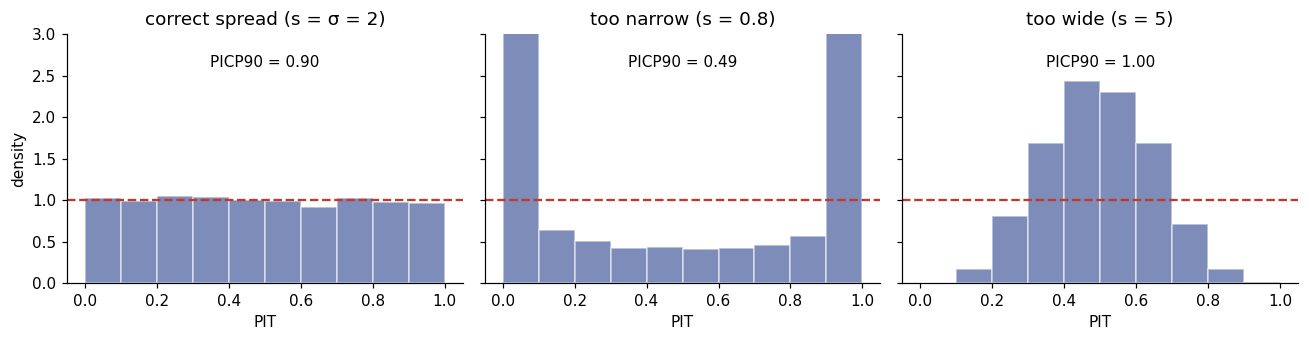

In [6]:
rng = np.random.default_rng(1)
e = 2.0 * rng.standard_normal(5000)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for a, s, name in zip(ax, [2.0, 0.8, 5.0], ["correct spread (s = σ = 2)", "too narrow (s = 0.8)", "too wide (s = 5)"]):
    u = norm.cdf(e / s)
    a.hist(u, bins=10, range=(0, 1), density=True, color=BLUE, alpha=0.6, edgecolor="white")
    a.axhline(1, color=RED, ls="--"); a.set_title(name); a.set_xlabel("PIT")
    a.text(0.5, 2.6, f"PICP90 = {np.mean(np.abs(e/s) <= 1.6449):.2f}", ha="center")
ax[0].set_ylabel("density"); ax[0].set_ylim(0, 3)
plt.tight_layout(); plt.show()